# Benchmark v5 — GPU — ESOL — scaffold split, seed 0

**Task:** Predict `log(mol/L)` solubility from molecular structure.
**Size:** ~1,128 molecules
**Metric:** RMSE ↓, MAE ↓, R² ↑

**Scaffold split**, seed **0** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_0/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "esol"
TASK_TYPE = "regression"
OUT_CHANNELS = 1
BATCH_SIZE = 32
GNN_EPOCHS = 120
LSTM_EPOCHS = 120
TOX21_TABULAR = False

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 20
print(f"GPU HPO tier: standard — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 0

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: standard — 20 trials, 80 epochs/trial, batch=32
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold
SPLIT_SEED=0  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("esol", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "esol")
print(f"Molecules : {len(smiles)}")
print(f"Target    : [{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.2f}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'esol' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/esol.csv
INFO | [esol] 1128 / 1128 valid molecules


Molecules : 1128
Target    : [-11.60, 1.58]  mean=-3.05
After bond filter: 1127 molecules


### Representations & scaffold split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


INFO | Loaded 1128 / 1128 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/esol_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/splits/esol_scaffold_splits.pkl


3D graphs loaded: 1128 / 1127 (valid_idx mapping)
{'n_total': 1127, 'n_train': 901, 'n_val': 113, 'n_test': 113, 'n_scaffolds_total': 269, 'n_scaffolds_train': 59, 'n_scaffolds_val': 97, 'n_scaffolds_test': 113}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 2D — starting trial 1/20 (layers=5, hidden=192)


→ GIN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=3.1358 | val={'RMSE': 1.9253941204564395, 'MAE': 1.3420941993198563, 'R2': 0.14762687548553954}
INFO | HPO epoch   5/80 | loss=1.2703 | val={'RMSE': 1.9901782377279167, 'MAE': 1.2618913637325826, 'R2': 0.08930194030035243}
INFO | HPO epoch  10/80 | loss=0.9115 | val={'RMSE': 2.1620671452737503, 'MAE': 1.366304204395387, 'R2': -0.0748028760946775}
INFO | HPO epoch  15/80 | loss=0.8809 | val={'RMSE': 1.6658318943355301, 'MAE': 0.9361533385462466, 'R2': 0.3619527941597219}
INFO | HPO epoch  20/80 | loss=0.8207 | val={'RMSE': 1.7712691520915005, 'MAE': 1.1258497752447043, 'R2': 0.2786274977041032}
INFO | HPO epoch  25/80 | loss=0.7359 | val={'RMSE': 1.9281717834147811, 'MAE': 1.056524053875324, 'R2': 0.14516575540823862}
INFO | HPO epoch  30/80 | loss=0.6537 | val={'RMSE': 1.3034195633338064, 'MAE': 0.9842429866569232, 'R2': 0.609375988589314}
INFO | Early stop at epoch 33 (patience=15)
INFO | GIN 2D HPO — trial 1/20 finished | val=0.943957 | best=0.943957
IN

   scaffold test: {'RMSE': 1.1571275718397427, 'MAE': 0.8690653527073101, 'R2': 0.6740178624660709}


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | DMPNN 2D — starting trial 1/20 (layers=5, hidden=192)


→ D-MPNN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=8.2076 | val={'RMSE': 1.9806203507898152, 'MAE': 1.4154431276616797, 'R2': 0.09802824177841907}
INFO | HPO epoch   5/80 | loss=1.2707 | val={'RMSE': 1.4361192351147223, 'MAE': 1.1930051000080013, 'R2': 0.5257891750701096}
INFO | HPO epoch  10/80 | loss=0.9948 | val={'RMSE': 1.3789644496021902, 'MAE': 1.1527449576332507, 'R2': 0.5627834376130191}
INFO | HPO epoch  15/80 | loss=0.8410 | val={'RMSE': 1.0497310182477468, 'MAE': 0.8145402261113699, 'R2': 0.746635055518843}
INFO | HPO epoch  20/80 | loss=0.6718 | val={'RMSE': 1.2967102052611255, 'MAE': 1.066034272477954, 'R2': 0.6133871160180913}
INFO | HPO epoch  25/80 | loss=0.6358 | val={'RMSE': 1.0091947458794386, 'MAE': 0.7968508719870474, 'R2': 0.7658250549920477}
INFO | HPO epoch  30/80 | loss=0.5096 | val={'RMSE': 0.9872689480087701, 'MAE': 0.7875620053866795, 'R2': 0.7758899045624195}
INFO | HPO epoch  35/80 | loss=0.4497 | val={'RMSE': 1.0098827800099945, 'MAE': 0.7748312214966369, 'R2': 0.76550564136

   scaffold test: {'RMSE': 1.1089122344192286, 'MAE': 0.8447821270839303, 'R2': 0.70061801115023}


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/20 (layers=5, hidden=192)


→ GIN (3D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=2.5385 | val={'RMSE': 1.5763180407418167, 'MAE': 1.1321428397060496, 'R2': 0.44263517737420943}
INFO | HPO epoch   5/80 | loss=1.2063 | val={'RMSE': 1.4308983614518613, 'MAE': 1.1267677695877785, 'R2': 0.5407285636925518}
INFO | HPO epoch  10/80 | loss=0.9223 | val={'RMSE': 1.6050668623989721, 'MAE': 1.243034469210996, 'R2': 0.4221193929074354}
INFO | HPO epoch  15/80 | loss=0.7415 | val={'RMSE': 1.500732997004627, 'MAE': 1.180975703077506, 'R2': 0.4948053689762226}
INFO | HPO epoch  20/80 | loss=0.6714 | val={'RMSE': 1.026227277553541, 'MAE': 0.8261093960135384, 'R2': 0.7637678668222609}
INFO | HPO epoch  25/80 | loss=0.6399 | val={'RMSE': 1.2651565353795535, 'MAE': 0.9741474105193552, 'R2': 0.6409620217227521}
INFO | HPO epoch  30/80 | loss=0.5523 | val={'RMSE': 0.9768974648149237, 'MAE': 0.7879753931697491, 'R2': 0.7859329479602348}
INFO | HPO epoch  35/80 | loss=0.4642 | val={'RMSE': 0.9167824906702688, 'MAE': 0.7419451517341411, 'R2': 0.8114682565216

   scaffold test: {'RMSE': 1.01315360365049, 'MAE': 0.7979908292799924, 'R2': 0.7666091084390754}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | SchNet — starting trial 1/20


→ SchNet (3D coords) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=5.8013 | val={'RMSE': 1.5110576094035497, 'MAE': 1.1691421222897758, 'R2': 0.4878302696844}
INFO | HPO epoch   5/80 | loss=0.9092 | val={'RMSE': 1.0925145380452153, 'MAE': 0.8739818339854215, 'R2': 0.7322642822359873}
INFO | HPO epoch  10/80 | loss=0.6954 | val={'RMSE': 1.1550102746363056, 'MAE': 0.9253988508629588, 'R2': 0.7007573042560638}
INFO | HPO epoch  15/80 | loss=0.5733 | val={'RMSE': 0.9450493878253111, 'MAE': 0.7416024838401153, 'R2': 0.799663134944157}
INFO | HPO epoch  20/80 | loss=0.6067 | val={'RMSE': 1.076100100865893, 'MAE': 0.8183089708332467, 'R2': 0.7402490124060375}
INFO | HPO epoch  25/80 | loss=0.4999 | val={'RMSE': 1.0726258615975983, 'MAE': 0.8268825225202383, 'R2': 0.7419235411980893}
INFO | HPO epoch  30/80 | loss=0.3808 | val={'RMSE': 1.0308934543663084, 'MAE': 0.7399888708528164, 'R2': 0.7616147240140195}
INFO | HPO epoch  35/80 | loss=0.3376 | val={'RMSE': 0.9990819950839, 'MAE': 0.7129514602433263, 'R2': 0.7760999822075216}


   scaffold test: {'RMSE': 0.9770426515283372, 'MAE': 0.7606745569315632, 'R2': 0.782949714501534}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/20


→ SMILES LSTM (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=11.3291 | val={'RMSE': 3.9806599733112153, 'MAE': 3.4488086661538193, 'R2': -2.643347777875815}
INFO | HPO epoch   5/80 | loss=2.5400 | val={'RMSE': 1.6527332632903589, 'MAE': 1.2902527106019248, 'R2': 0.3719474242184626}
INFO | HPO epoch  10/80 | loss=0.9874 | val={'RMSE': 1.2828190332788336, 'MAE': 1.0443513972305618, 'R2': 0.621626026960213}
INFO | HPO epoch  15/80 | loss=0.7312 | val={'RMSE': 1.1837470517768105, 'MAE': 0.9487886971472639, 'R2': 0.677812797434811}
INFO | HPO epoch  20/80 | loss=0.6494 | val={'RMSE': 1.1396875397096995, 'MAE': 0.9320285692151669, 'R2': 0.7013503118755893}
INFO | HPO epoch  25/80 | loss=0.5694 | val={'RMSE': 1.1061390120041503, 'MAE': 0.9011369644936207, 'R2': 0.7186739914818038}
INFO | HPO epoch  30/80 | loss=0.4863 | val={'RMSE': 1.0692906045385733, 'MAE': 0.8829214004882141, 'R2': 0.7371052175122166}
INFO | HPO epoch  35/80 | loss=0.4719 | val={'RMSE': 1.067839811156559, 'MAE': 0.8763269692395641, 'R2': 0.737818114954

   scaffold test: {'RMSE': 0.8901669496200572, 'MAE': 0.6990935540041038, 'R2': 0.8070813338857233}


### Finalize GPU + merge


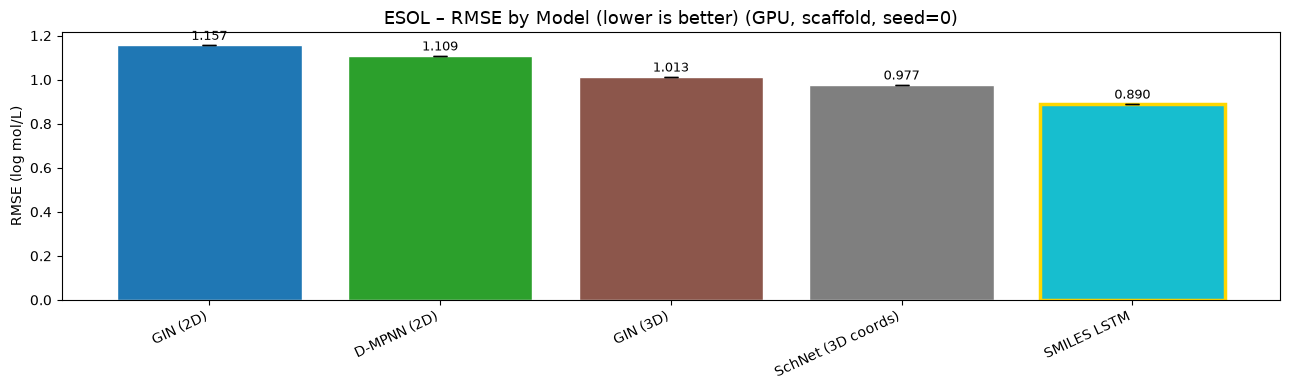

=== ESOL Results (5/12 models) ===
                               RMSE              MAE               R2
Model                                                                
GIN (2D)            1.1571 ± 0.0000  0.8691 ± 0.0000  0.6740 ± 0.0000
D-MPNN (2D)         1.1089 ± 0.0000  0.8448 ± 0.0000  0.7006 ± 0.0000
GIN (3D)            1.0132 ± 0.0000  0.7980 ± 0.0000  0.7666 ± 0.0000
SchNet (3D coords)  0.9770 ± 0.0000  0.7607 ± 0.0000  0.7829 ± 0.0000
SMILES LSTM         0.8902 ± 0.0000  0.6991 ± 0.0000  0.8071 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/esol_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/esol_rmse_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results

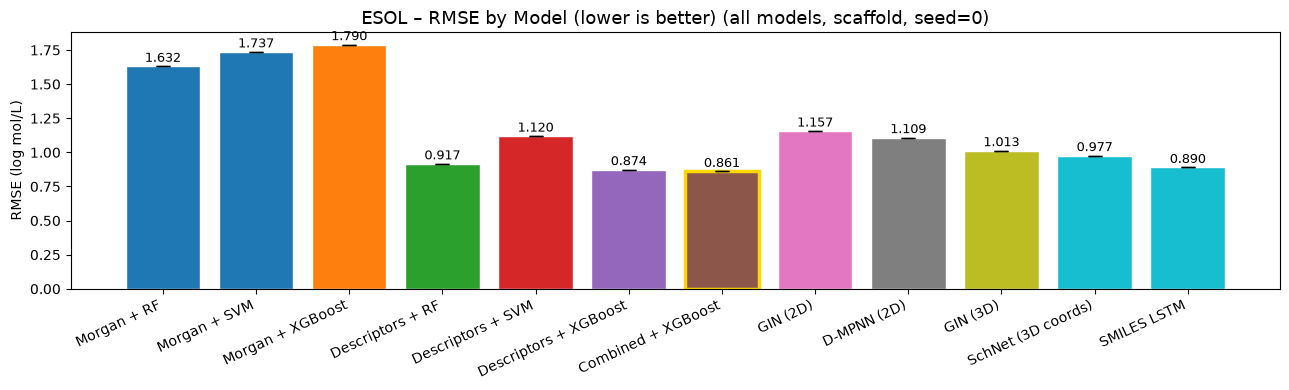

=== ESOL Results (12/12 models) ===
                                  RMSE              MAE               R2
Model                                                                   
Morgan + RF            1.6316 ± 0.0000  1.2585 ± 0.0000  0.3519 ± 0.0000
Morgan + SVM           1.7372 ± 0.0000  1.3448 ± 0.0000  0.2653 ± 0.0000
Morgan + XGBoost       1.7902 ± 0.0000  1.4639 ± 0.0000  0.2197 ± 0.0000
Descriptors + RF       0.9165 ± 0.0000  0.6913 ± 0.0000  0.7955 ± 0.0000
Descriptors + SVM      1.1200 ± 0.0000  0.7971 ± 0.0000  0.6946 ± 0.0000
Descriptors + XGBoost  0.8741 ± 0.0000  0.6591 ± 0.0000  0.8140 ± 0.0000
Combined + XGBoost     0.8610 ± 0.0000  0.6482 ± 0.0000  0.8195 ± 0.0000
GIN (2D)               1.1571 ± 0.0000  0.8691 ± 0.0000  0.6740 ± 0.0000
D-MPNN (2D)            1.1089 ± 0.0000  0.8448 ± 0.0000  0.7006 ± 0.0000
GIN (3D)               1.0132 ± 0.0000  0.7980 ± 0.0000  0.7666 ± 0.0000
SchNet (3D coords)     0.9770 ± 0.0000  0.7607 ± 0.0000  0.7829 ± 0.0000
SMILES LSTM    

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"ESOL – RMSE by Model (lower is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (log mol/L)", minimize=True)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"ESOL – RMSE by Model (lower is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (log mol/L)", minimize=True)
else:
    print("Run CPU notebook first for combined results.")
